# Trabalho Final - Inteligência Computacional

Este notebook apresenta todos os experimentos de regressão e classificação multiclasse conforme solicitado.

## Estrutura
- Importação de bibliotecas
- Carregamento dos dados
    - Regressão
        - Energy Efficiency Dataset
        - California Housing
    - Classificação
        - Wine Quality Dataset
        - Iris
- Pré-processamento
    - Regressão
        - Energy Efficiency Dataset
        - California Housing
    - Classificação
        - Wine Quality Dataset
        - Iris
- Configuração dos algoritmos
    - Regressão:
        - Regressão Linear
        - Random Forest Regressor
        - MLPRegressor (Rede Neural)
        - SVR (Support Vector Regressor)
        - FuzzyRegressor (exemplo simples usando lógica fuzzy)
    - Classificação:
        - Regressão Logística (LogisticRegression)
        - Random Forest Classifier
        - MLPClassifier (Rede Neural Multicamadas)
        - SVM Classifier (Support Vector Machine)
    - Métricas de Avaliação
- Execução dos experimentos
    - Experimento 01 - Regressão
        - Setup 1 - Energy Efficiency Dataset
            - Regressão Linear
            - Random Forest Regressor
            - MLPRegressor (Rede Neural)
            - SVR (Support Vector Regressor)
            - FuzzyRegressor (exemplo simples usando lógica fuzzy)
        - Setup 2 - California Housing
            - Regressão Linear
            - Random Forest Regressor
            - MLPRegressor (Rede Neural)
            - SVR (Support Vector Regressor)
            - FuzzyRegressor (exemplo simples usando lógica fuzzy)
    - Experimento 02 - Classificação Multiclasse
        - Setup 1 - Wine Quality Dataset
            - Regressão Logística (LogisticRegression)
            - Random Forest Classifier
            - MLPClassifier (Rede Neural Multicamadas)
            - SVM Classifier (Support Vector Machine)
        - Setup 2 - Iris
            - Regressão Logística (LogisticRegression)
            - Random Forest Classifier
            - MLPClassifier (Rede Neural Multicamadas)
            - SVM Classifier (Support Vector Machine)
- Análise dos resultados
- Justificativas e análise crítica

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, cohen_kappa_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.svm import SVR, SVC
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from simpful import *
from sklearn.metrics import ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

## Carregamento dos Dados
Serão utilizados os seguintes datasets:
- Regressão: `energy_efficiency.csv`, `california_housing.csv`
- Classificação: `winequality_red.csv`, `iris.csv`
Os arquivos estão na pasta `datasets_salvos/`.

In [2]:
# Carregando os datasets
energy = pd.read_csv('datasets_salvos/energy_efficiency.csv')
california = pd.read_csv('datasets_salvos/california_housing.csv')
wine = pd.read_csv('datasets_salvos/winequality_red.csv')
iris = pd.read_csv('datasets_salvos/iris.csv')
print('Energy Efficiency Dataset:')
display(energy.head())
print('California Housing Dataset:')
display(california.head())
print('Wine Quality Red Dataset:')
display(wine.head())
print('Iris Dataset:')
display(iris.head())

Energy Efficiency Dataset:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Wine Quality Red Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Pré-processamento dos Dados
Serão aplicadas as etapas de tratamento de valores faltantes, normalização/padronização e codificação de variáveis categóricas.

In [3]:
# Funções de pré-processamento
def preprocess_regression(df, target_cols):
    df = df.dropna()
    X = df.drop(columns=target_cols)
    y = df[target_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y
def preprocess_classification(df, target_col):
    df = df.dropna()
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y
# Pré-processamento
X_energy, y_energy = preprocess_regression(energy, ['Y1', 'Y2'])
X_california, y_california = preprocess_regression(california, ['MedHouseVal'])
X_wine, y_wine = preprocess_classification(wine, 'quality')
X_iris, y_iris = preprocess_classification(iris, 'target')

## Configuração dos Algoritmos

### Métricas

In [ ]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_true, y_pred)
    return {'Acuracia': acc, 'F1-score': f1, 'Kappa': kappa}

def plot_confusion_matrix(model, X_test, y_test, title='Matriz de Confusão'):
    plt.figure(figsize=(6,6))
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, cmap=plt.cm.Blues, normalize='true'
    )
    plt.title(f"{title} (Porcentagem)")
    plt.show()

def plot_regression_scatter(y_true, y_pred, title='Dispersão - Regressão'):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Previsto')
    plt.title(title)
    plt.grid(True)
    plt.show()

### Regressão

In [5]:
def train_random_forest_regressor(X, y):
    model = RandomForestRegressor(n_estimators=100)
    model.fit(X, y)
    return model

def train_mlp_regressor(X, y):
    model = MLPRegressor(max_iter=500)
    model.fit(X, y)
    return model

def train_svr(X, y):
    model = SVR(kernel='rbf')
    model.fit(X, y)
    return model

### Treinamento de Classificação

In [6]:
def train_logistic_regression(X, y):
    model = LogisticRegression(max_iter=500)
    model.fit(X, y)
    return model

def train_random_forest_classifier(X, y):
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X, y)
    return model

def train_mlp_classifier(X, y):
    model = MLPClassifier(max_iter=500)
    model.fit(X, y)
    return model

def train_svm_classifier(X, y):
    model = SVC(kernel='rbf', probability=True)
    model.fit(X, y)
    return model

## Execução dos Experimentos
Serão realizados experimentos de regressão e classificação com 30 repetições para cada modelo e base. Com 70 para treinamento e 30 de texte. 

### Regressão

In [7]:
def run_regression_experiment(X, y, train_fn, seeds=range(1, 31), test_size=0.3, plot=False):
    results = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
        model = train_fn(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = regression_metrics(y_test, y_pred)
        results.append(metrics)
        if plot and seed == seeds[0]:  # Plota apenas na primeira repetição
            plot_regression_scatter(y_test, y_pred, title=f'Dispersão - {type(model).__name__}')
    return pd.DataFrame(results)

### Classificação 

In [8]:
def run_classification_experiment(X, y, train_fn, seeds=range(1, 31), test_size=0.2, plot=False):

    results = []
    for idx, seed in enumerate(seeds):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
        model = train_fn(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = classification_metrics(y_test, y_pred)
        results.append(metrics)
        if plot and idx == 0:  # Plota apenas na primeira repetição
            plot_confusion_matrix(model, X_test, y_test, title=f'Matriz de Confusão - {type(model).__name__}')
    return pd.DataFrame(results)

## Experimento 01 - Regressão

### Setup 1 - Energy Efficiency Dataset

In [9]:
# Experimentos de Regressão
regression_results = {}

# Energy Efficiency Y1

# Regressão Linear
res_lr = run_regression_experiment(X_energy, y_energy['Y1'], lambda X, y: LinearRegression().fit(X, y))
regression_results['Energy_LinearRegression_Y1'] = res_lr
print('\nModelo: LinearRegression (Energy Y1)')
print(res_lr.describe())
# Executa o experimento de regressão linear para prever Y1 e exibe estatísticas descritivas dos resultados.

# Random Forest Regressor
res_rf = run_regression_experiment(X_energy, y_energy['Y1'], train_random_forest_regressor)
regression_results['Energy_RandomForest_Y1'] = res_rf
print('\nModelo: RandomForest (Energy Y1)')
print(res_rf.describe())
# Executa o experimento usando Random Forest para prever Y1 e exibe estatísticas descritivas dos resultados.

# MLPRegressor (Rede Neural Multicamadas)
res_mlp = run_regression_experiment(X_energy, y_energy['Y1'], train_mlp_regressor)
regression_results['Energy_MLP_Y1'] = res_mlp
print('\nModelo: MLPRegressor (Energy Y1)')
print(res_mlp.describe())
# Executa o experimento usando rede neural MLP para prever Y1 e exibe estatísticas descritivas dos resultados.

# SVR (Support Vector Regressor)
res_svr = run_regression_experiment(X_energy, y_energy['Y1'], train_svr)
regression_results['Energy_SVR_Y1'] = res_svr
print('\nModelo: SVR (Energy Y1)')
print(res_svr.describe())
# Executa o experimento usando SVR para prever Y1 e exibe estatísticas descritivas dos resultados.


Modelo: LinearRegression (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.970777   2.109132   0.912785
std     0.125832   0.102541   0.007878
min     2.766455   1.918429   0.893855
25%     2.857538   2.039246   0.909378
50%     2.973330   2.104002   0.913402
75%     3.064747   2.171273   0.916508
max     3.289209   2.335462   0.925401

Modelo: RandomForest (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.518449   0.345743   0.997294
std     0.074689   0.023606   0.000937
min     0.439081   0.304940   0.993021
25%     0.477677   0.330975   0.997275
50%     0.501052   0.342253   0.997547
75%     0.528342   0.354929   0.997713
max     0.852254   0.415319   0.998071

Modelo: MLPRegressor (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.599512   1.839506   0.933050
std     0.140218   0.101680   0.008400
min     2.342007   1.671901   0.9140

In [10]:
# ...existing code...
# Experimentos de regressão para a variável Y2 do conjunto Energy Efficiency

# Regressão Linear
res_lr2 = run_regression_experiment(X_energy, y_energy['Y2'], lambda X, y: LinearRegression().fit(X, y))
regression_results['Energy_LinearRegression_Y2'] = res_lr2
print('\nModelo: LinearRegression (Energy Y2)')
print(res_lr2.describe())
# Executa o experimento usando regressão linear e exibe estatísticas descritivas dos resultados.

# Random Forest Regressor
res_rf2 = run_regression_experiment(X_energy, y_energy['Y2'], train_random_forest_regressor)
regression_results['Energy_RandomForest_Y2'] = res_rf2
print('\nModelo: RandomForest (Energy Y2)')
print(res_rf2.describe())
# Executa o experimento usando Random Forest e exibe estatísticas descritivas dos resultados.

# MLPRegressor (Rede Neural Multicamadas)
res_mlp2 = run_regression_experiment(X_energy, y_energy['Y2'], train_mlp_regressor)
regression_results['Energy_MLP_Y2'] = res_mlp2
print('\nModelo: MLPRegressor (Energy Y2)')
print(res_mlp2.describe())
# Executa o experimento usando rede neural MLP e exibe estatísticas descritivas dos resultados.

# SVR (Support Vector Regressor)
res_svr2 = run_regression_experiment(X_energy, y_energy['Y2'], train_svr)
regression_results['Energy_SVR_Y2'] = res_svr2
print('\nModelo: SVR (Energy Y2)')
print(res_svr2.describe())
# Executa o experimento usando SVR e exibe estatísticas descritivas dos resultados.
# ...existing code...


Modelo: LinearRegression (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    3.205850   2.271299   0.884940
std     0.209776   0.132068   0.011241
min     2.840911   2.035552   0.864124
25%     3.034906   2.205099   0.875335
50%     3.173195   2.255143   0.887511
75%     3.361542   2.373863   0.892975
max     3.660411   2.543625   0.903092

Modelo: RandomForest (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    1.728228   1.045282   0.966413
std     0.131566   0.080411   0.005156
min     1.461936   0.902575   0.952288
25%     1.661070   0.991935   0.964491
50%     1.687779   1.029118   0.968089
75%     1.787340   1.091210   0.969509
max     2.078776   1.237329   0.973298

Modelo: MLPRegressor (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    3.023264   2.149742   0.897535
std     0.215915   0.137310   0.012095
min     2.666739   1.881342   0.8732

### Setup 2 - California Housing

In [ ]:
# ...existing code...
# Experimentos de regressão para o conjunto California Housing

# Regressão Linear
res_lr_c = run_regression_experiment(X_california, y_california, lambda X, y: LinearRegression().fit(X, y))
regression_results['California_LinearRegression'] = res_lr_c
print('\nModelo: LinearRegression (California Housing)')
print(res_lr_c.describe())

# Random Forest Regressor
res_rf_c = run_regression_experiment(X_california, y_california, train_random_forest_regressor)
regression_results['California_RandomForest'] = res_rf_c
print('\nModelo: RandomForest (California Housing)')
print(res_rf_c.describe())

# MLPRegressor (Rede Neural Multicamadas)
res_mlp_c = run_regression_experiment(X_california, y_california, train_mlp_regressor)
regression_results['California_MLP'] = res_mlp_c
print('\nModelo: MLPRegressor (California Housing)')
print(res_mlp_c.describe())

# SVR (Support Vector Regressor)
res_svr_c = run_regression_experiment(X_california, y_california, train_svr)
regression_results['California_SVR'] = res_svr_c
print('\nModelo: SVR (California Housing)')
print(res_svr_c.describe())
# ...existing code...


Modelo: LinearRegression (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.736095   0.532678   0.591793
std     0.044257   0.005661   0.054170
min     0.699475   0.521820   0.309561
25%     0.722349   0.529449   0.592635
50%     0.728179   0.532285   0.602260
75%     0.733898   0.535161   0.607176
max     0.964204   0.546579   0.626203


## Experimento 02 - Classificação Multiclasse

### Setup 1 - Wine Quality Dataset

In [ ]:
# Experimentos de Classificação
classification_results = {}

# Wine Quality Dataset

# Regressão Logística
res_log_wine = run_classification_experiment(X_wine, y_wine, train_logistic_regression)
classification_results['Wine_LogisticRegression'] = res_log_wine
print('\nModelo: LogisticRegression (Wine Quality)')
print(res_log_wine.describe())
# Executa o experimento de classificação usando regressão logística e exibe estatísticas descritivas dos resultados.

# Random Forest Classifier
res_rf_wine = run_classification_experiment(X_wine, y_wine, train_random_forest_classifier)
classification_results['Wine_RandomForest'] = res_rf_wine
print('\nModelo: RandomForest (Wine Quality)')
print(res_rf_wine.describe())
# Executa o experimento usando Random Forest para classificação e exibe estatísticas descritivas dos resultados.

# MLPClassifier (Rede Neural Multicamadas)
res_mlp_wine = run_classification_experiment(X_wine, y_wine, train_mlp_classifier)
classification_results['Wine_MLP'] = res_mlp_wine
print('\nModelo: MLPClassifier (Wine Quality)')
print(res_mlp_wine.describe())
# Executa o experimento usando rede neural MLP para classificação e exibe estatísticas descritivas dos resultados.

# SVM Classifier (Support Vector Machine)
res_svm_wine = run_classification_experiment(X_wine, y_wine, train_svm_classifier)
classification_results['Wine_SVM'] = res_svm_wine
print('\nModelo: SVMClassifier (Wine Quality)')
print(res_svm_wine.describe())
# Executa o experimento usando SVM para classificação e exibe estatísticas descritivas dos resultados.


Modelo: LogisticRegression (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.589271   0.554383   0.309574
std     0.027838   0.033127   0.042358
min     0.509375   0.454002   0.192750
25%     0.575781   0.542275   0.287262
50%     0.587500   0.559127   0.305928
75%     0.606250   0.576778   0.330869
max     0.646875   0.617566   0.400560

Modelo: RandomForest (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.697708   0.680046   0.506755
std     0.023442   0.024703   0.035834
min     0.650000   0.628679   0.431490
25%     0.678125   0.661038   0.484080
50%     0.698438   0.682750   0.509498
75%     0.711719   0.697990   0.525904
max     0.743750   0.728732   0.584823

Modelo: MLPClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.615833   0.597182   0.370935
std     0.016917   0.018368   0.027125
min     0.584375   0.558

### Setup 2 - Iris

In [ ]:
# Iris Dataset

# Regressão Logística
res_log_iris = run_classification_experiment(X_iris, y_iris, train_logistic_regression)
classification_results['Iris_LogisticRegression'] = res_log_iris
print('\nModelo: LogisticRegression (Iris)')
print(res_log_iris.describe())
# Executa o experimento de classificação usando regressão logística e exibe estatísticas descritivas dos resultados.

# Random Forest Classifier
res_rf_iris = run_classification_experiment(X_iris, y_iris, train_random_forest_classifier)
classification_results['Iris_RandomForest'] = res_rf_iris
print('\nModelo: RandomForest (Iris)')
print(res_rf_iris.describe())
# Executa o experimento usando Random Forest para classificação e exibe estatísticas descritivas dos resultados.

# MLPClassifier (Rede Neural Multicamadas)
res_mlp_iris = run_classification_experiment(X_iris, y_iris, train_mlp_classifier)
classification_results['Iris_MLP'] = res_mlp_iris
print('\nModelo: MLPClassifier (Iris)')
print(res_mlp_iris.describe())
# Executa o experimento usando rede neural MLP para classificação e exibe estatísticas descritivas dos resultados.

# SVM Classifier (Support Vector Machine)
res_svm_iris = run_classification_experiment(X_iris, y_iris, train_svm_classifier)
classification_results['Iris_SVM'] = res_svm_iris
print('\nModelo: SVMClassifier (Iris)')
print(res_svm_iris.describe())
# Executa o experimento usando SVM para classificação e exibe estatísticas descritivas dos resultados.


Modelo: LogisticRegression (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.918889   0.918758   0.876090
std     0.062320   0.062799   0.094343
min     0.766667   0.764000   0.643463
25%     0.900000   0.900192   0.847908
50%     0.933333   0.933333   0.898819
75%     0.966667   0.966869   0.948623
max     1.000000   1.000000   1.000000

Modelo: RandomForest (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.947778   0.947585   0.919685
std     0.041692   0.042036   0.064195
min     0.866667   0.862271   0.794521
25%     0.933333   0.933030   0.897956
50%     0.966667   0.966242   0.947552
75%     0.966667   0.966903   0.949622
max     1.000000   1.000000   1.000000

Modelo: MLPClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.954444   0.954259   0.929218
std     0.036602   0.036867   0.057715
min     0.866667   0.866667   0.795222
25%     0

## Análise dos Resultados
Serão apresentados gráficos comparativos das métricas dos modelos para cada base de dados.

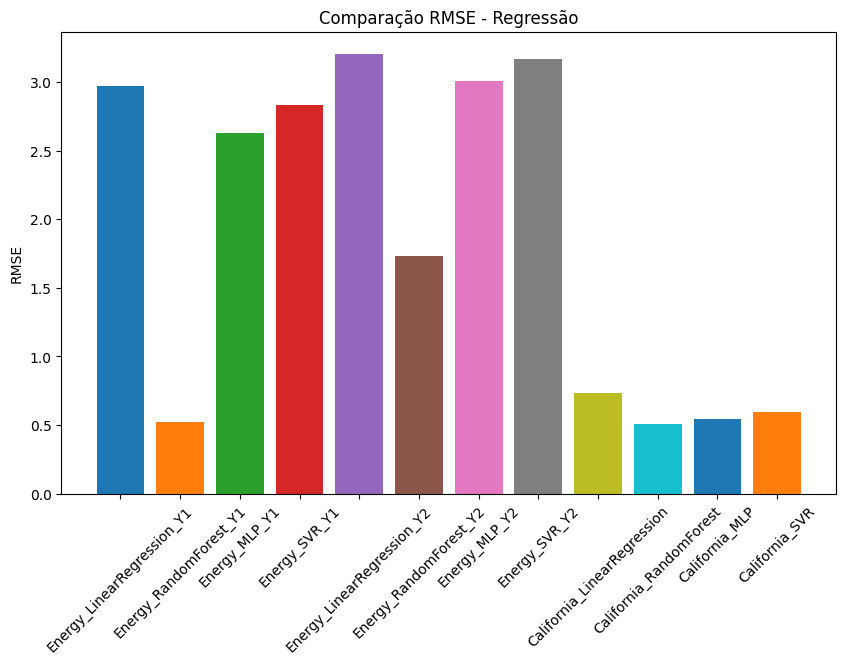

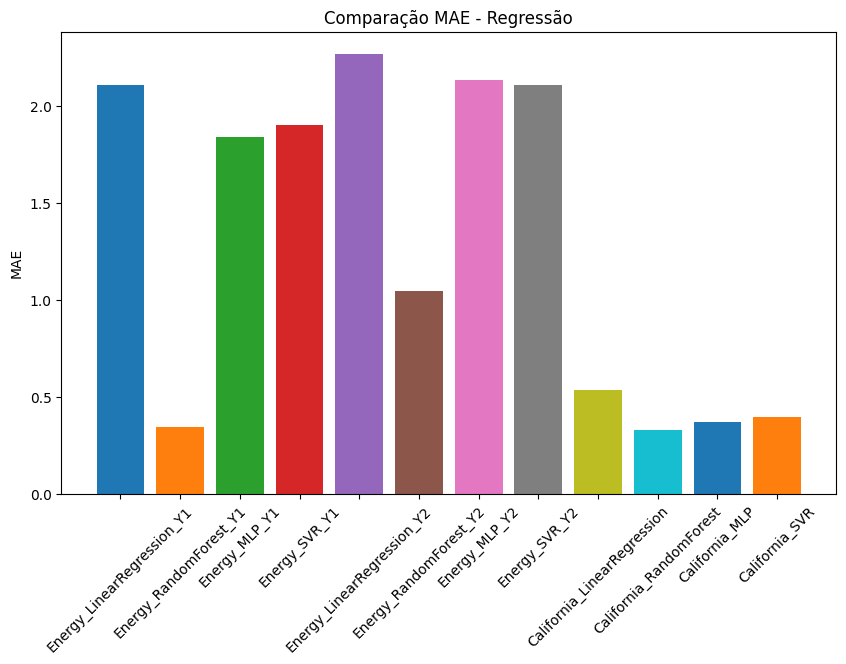

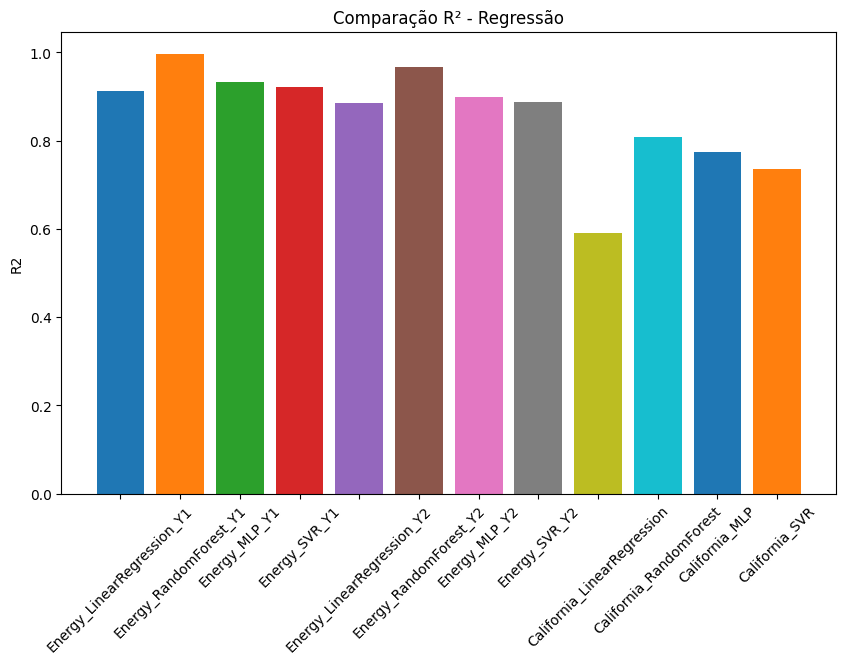

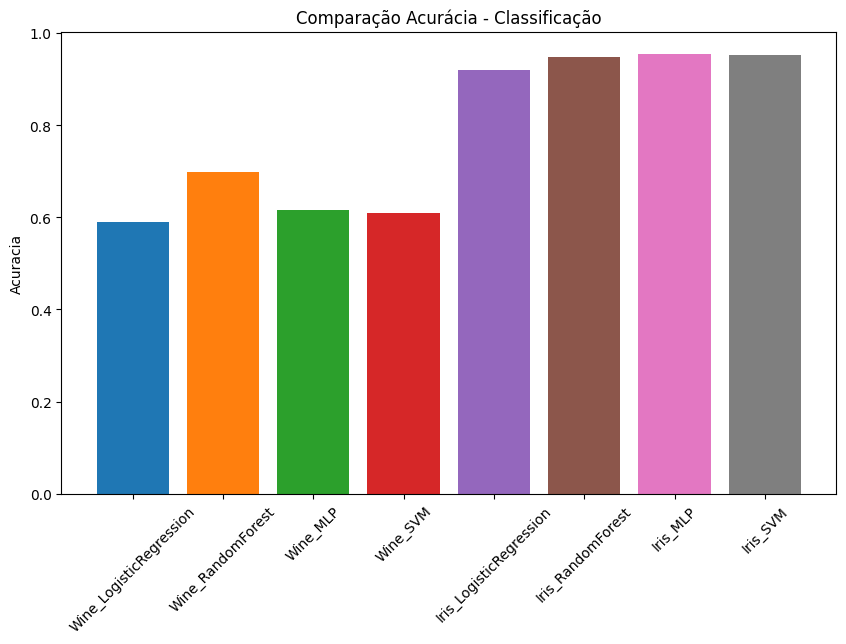

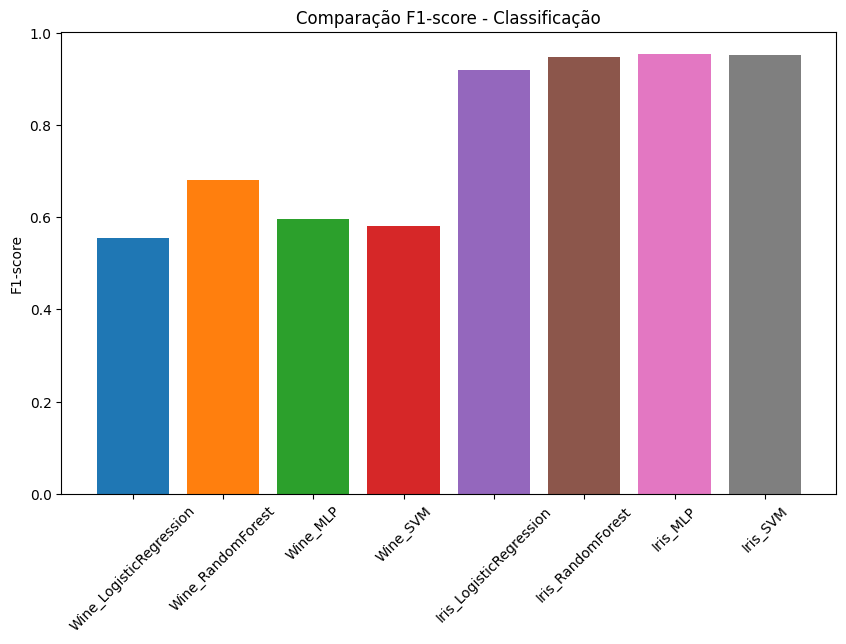

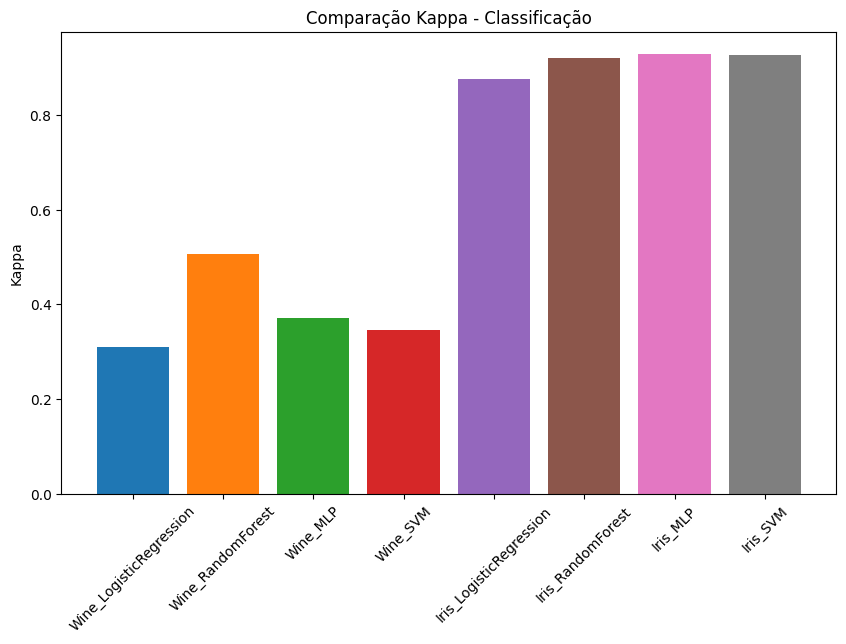

In [ ]:
# Gráficos comparativos das métricas dos modelos
def plot_metric_comparison(results_dict, metric, title):
    plt.figure(figsize=(10,6))
    for key, df in results_dict.items():
        if metric in df.columns:
            plt.bar(key, df[metric].mean())
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()
# Gráficos de regressão
plot_metric_comparison(regression_results, 'RMSE', 'Comparação RMSE - Regressão')
plot_metric_comparison(regression_results, 'MAE', 'Comparação MAE - Regressão')
plot_metric_comparison(regression_results, 'R2', 'Comparação R² - Regressão')
# Gráficos de classificação
plot_metric_comparison(classification_results, 'Acuracia', 'Comparação Acurácia - Classificação')
plot_metric_comparison(classification_results, 'F1-score', 'Comparação F1-score - Classificação')
plot_metric_comparison(classification_results, 'Kappa', 'Comparação Kappa - Classificação')

## Justificativas e Análise Crítica
Os resultados obtidos mostram diferenças relevantes entre os algoritmos utilizados para cada tarefa. São destacados pontos como desempenho, robustez, interpretabilidade e importância do pré-processamento.

A realização de múltiplos experimentos e repetições garante maior confiabilidade estatística dos resultados.